In [125]:
import torch
from matplotlib import pyplot as plt
from torch import Tensor
from torch.nn import functional as F
from torch.utils.data import TensorDataset
from torch_geometric.data import DataLoader
from tqdm import tqdm

from common import G2OpGymEnv, BusConnectivityGraphObsSpace, NODES, EDGE_INDEX
from nri import prior_from_env, Encoder
from nri.agent.graphormer.GraphormerEncoder import GraphormerNRIEncoder

In [126]:
env = G2OpGymEnv(obs_space_creation=lambda e: BusConnectivityGraphObsSpace(e.observation_space))
prior = prior_from_env(0.9, env)
ds_size = 1
node_features = []
edge_indices = []
outputs = []
for _ in tqdm(range(ds_size), "Create Dataset"):
    node_features.append(torch.from_numpy(env.reset()[0][NODES]))
    edge_indices.append(torch.from_numpy(env.reset()[0][EDGE_INDEX]))
    outputs.append(prior)

ds = TensorDataset(torch.stack(node_features, 0), torch.stack(edge_indices, 0), torch.stack(outputs, 0))
loader = DataLoader(ds, batch_size=1, shuffle=True)

2025-11-19 15:47:54,174 - common.constants - INFO - Using graph observation space with 57 nodes, ≤ 244 edges and 8 features per node (active_power_forecast, reactive_power_forecast, active_power, reactive_power, voltage, voltage_angle, current, rho).
2025-11-19 15:47:54,185 - common.constants - INFO - Prior for graph edges: tensor([0.9000, 0.1000]), Prior for non graph edges: tensor([0.0541, 0.9459])
Create Dataset: 100%|██████████| 1/1 [00:01<00:00,  1.70s/it]
/home/adrian/.conda/envs/RL/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [127]:
graphormer_encoder = GraphormerNRIEncoder(x_dim=env.observation_space.x_dim, hidden_dim=2, num_edge_types=2, max_degree=8, max_path_distance=9)
nri_encoder = Encoder(x_dim=env.observation_space.x_dim, hidden_dim=2, num_edge_types=2, dropout_prob=0.0)
lr_large = 0.1
lr_small = 0.001

losses = {
    graphormer_encoder: {
        lr_small: [],
        lr_large: []
    },
    nri_encoder: {
        lr_small: [],
        lr_large: []
    }
}
for encoder in [graphormer_encoder, nri_encoder]:
    for lr in [lr_small, lr_large]:
        optimizer = torch.optim.Adam(encoder.parameters(), lr=lr)

        num_epochs = int(10 / lr)
        for epoch in range(num_epochs):
            total_loss = 0.0
            for x, edge_index, label in loader:
                optimizer.zero_grad()
                B, N, X_dim = x.shape
                E = N * (N - 1)
                x = x.reshape(B * N, -1)
                batch = torch.arange(B).repeat_interleave(N)
                edge_logits = encoder.forward(x, batch=batch, powerline_edge_index=edge_index[0])
                edge_probs = F.softmax(edge_logits, dim=-1).reshape(B, E, 2)
                loss = (edge_probs * (torch.log(edge_probs + 0.0000001) - torch.log(label + 0.0000001))).sum(dim=-1).mean()
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            losses[encoder][lr].append(total_loss/len(ds))
            print(f"Epoch {epoch}, Loss: {total_loss/len(ds)}")

Epoch 0, Loss: 1.071160912513733
Epoch 1, Loss: 1.0700669288635254
Epoch 2, Loss: 1.0689733028411865
Epoch 3, Loss: 1.0678796768188477
Epoch 4, Loss: 1.0667861700057983
Epoch 5, Loss: 1.0656931400299072
Epoch 6, Loss: 1.0646001100540161
Epoch 7, Loss: 1.0635075569152832
Epoch 8, Loss: 1.0624150037765503
Epoch 9, Loss: 1.061322808265686
Epoch 10, Loss: 1.0602308511734009
Epoch 11, Loss: 1.0591391324996948
Epoch 12, Loss: 1.0580475330352783
Epoch 13, Loss: 1.056956171989441
Epoch 14, Loss: 1.0558651685714722
Epoch 15, Loss: 1.054774522781372
Epoch 16, Loss: 1.0536837577819824
Epoch 17, Loss: 1.05259370803833
Epoch 18, Loss: 1.0515035390853882
Epoch 19, Loss: 1.050413966178894
Epoch 20, Loss: 1.0493242740631104
Epoch 21, Loss: 1.0482351779937744
Epoch 22, Loss: 1.047146201133728
Epoch 23, Loss: 1.0460574626922607
Epoch 24, Loss: 1.0449689626693726
Epoch 25, Loss: 1.0438809394836426
Epoch 26, Loss: 1.0427931547164917
Epoch 27, Loss: 1.0417054891586304
Epoch 28, Loss: 1.0406181812286377
Epo

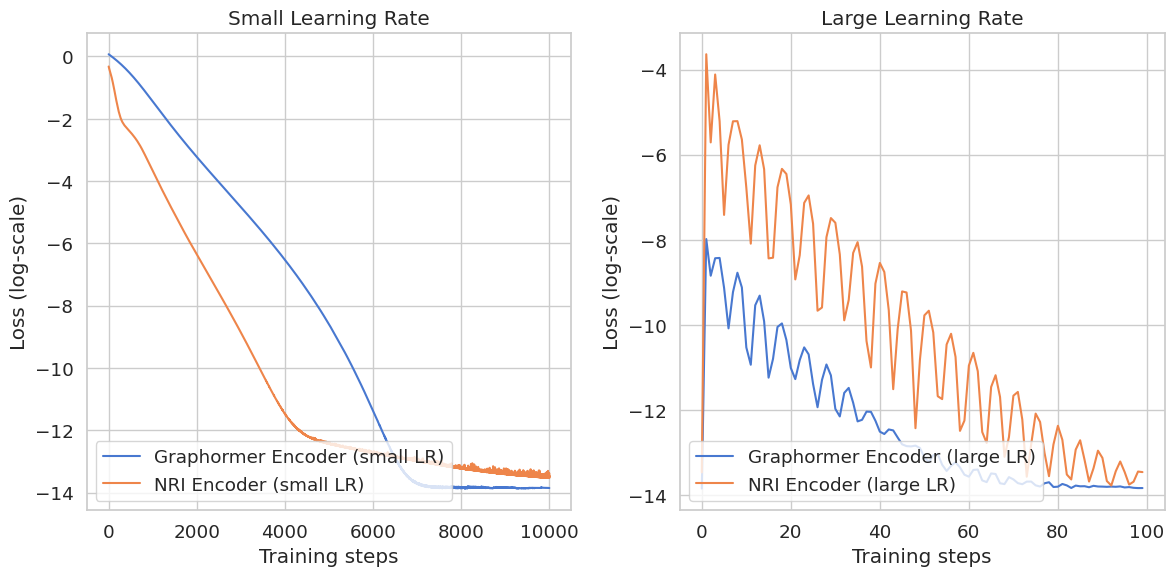

In [128]:
eps = 0.000001

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot for small learning rate
axs[0].plot(torch.log(Tensor(losses[graphormer_encoder][lr_small]) + eps), label="Graphormer Encoder (small LR)")
axs[0].plot(torch.log(Tensor(losses[nri_encoder][lr_small]) + eps), label="NRI Encoder (small LR)")
axs[0].legend(loc='lower left')
axs[0].set_xlabel("Training steps")
axs[0].set_ylabel("Loss (log-scale)")
axs[0].set_title("Small Learning Rate")

# Plot for large learning rate
axs[1].plot(torch.log(Tensor(losses[graphormer_encoder][lr_large]) + eps), label="Graphormer Encoder (large LR)")
axs[1].plot(torch.log(Tensor(losses[nri_encoder][lr_large]) + eps), label="NRI Encoder (large LR)")
axs[1].legend(loc='lower left')
axs[1].set_xlabel("Training steps")
axs[1].set_ylabel("Loss (log-scale)")
axs[1].set_title("Large Learning Rate")

# Adjust layout for better spacing
plt.tight_layout()

# Show the combined plot
plt.show()

Graphormer encoder is able to approximate the prior equally well as the NRI Encoder. Since it has a more general understanding of the structure of the powergrid, it is likely better suited to make predictions for latent graph structures. For small learning rates we can observe a slower convergence than for the NRI encoder initially.